## The Libraries Required 

Installs the libraries needed for:

pandas → data handling
matplotlib & seaborn → visualizations

In [2]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("C:\\Users\\MAGWALI\\Downloads\\ai_job_market_insights.csv")
print(df.head())
print(df.info())

               Job_Title       Industry Company_Size   Location  \
0  Cybersecurity Analyst  Entertainment        Small      Dubai   
1   Marketing Specialist     Technology        Large  Singapore   
2          AI Researcher     Technology        Large  Singapore   
3          Sales Manager         Retail        Small     Berlin   
4  Cybersecurity Analyst  Entertainment        Small      Tokyo   

  AI_Adoption_Level Automation_Risk     Required_Skills     Salary_USD  \
0            Medium            High        UX/UI Design  111392.165243   
1            Medium            High           Marketing   93792.562466   
2            Medium            High        UX/UI Design  107170.263069   
3               Low            High  Project Management   93027.953758   
4               Low             Low          JavaScript   87752.922171   

  Remote_Friendly Job_Growth_Projection  
0             Yes                Growth  
1              No               Decline  
2             Yes         

# Data Cleaning & Preprocessing

Removes duplicate rows
Removes missing values
Cleans column names

In [4]:
df = df.drop_duplicates()
df = df.dropna()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Exploratory Data Analysis (EDA)

describe() → summary stats (mean, min, max, etc.)
value_counts() → shows how often each category appears

In [5]:
print(df.describe())
print(df['industry'].value_counts())

          salary_usd
count     500.000000
mean    91222.390974
std     20504.291453
min     31969.526346
25%     78511.514863
50%     91998.195286
75%    103971.282092
max    155209.821614
industry
Manufacturing         58
Education             57
Technology            56
Finance               53
Telecommunications    53
Energy                49
Entertainment         47
Retail                46
Healthcare            42
Transportation        39
Name: count, dtype: int64


## Correlation Analysis

Converts text categories into numbers
Creates a correlation matrix to see relationships between variables

In [6]:
df['ai_adoption_level'] = df['ai_adoption_level'].map({
    'Low': 1, 'Medium': 2, 'High': 3
})
corr = df.corr(numeric_only=True)

## Visualizations

Shows relationships between variables (e.g., job growth vs AI adoption)


## AI Adoption Level vs Job Growth

This visualization examines the relationship between AI adoption levels and job growth outcomes. The chart shows that jobs with higher levels of AI adoption tend to be associated with growth more frequently than decline. In contrast, roles with low AI adoption display a more balanced or less pronounced growth pattern. This suggests that AI is not simply replacing jobs but may also be contributing to the creation of new opportunities and the expansion of existing roles. Overall, the pattern indicates a positive association between AI adoption and job growth.

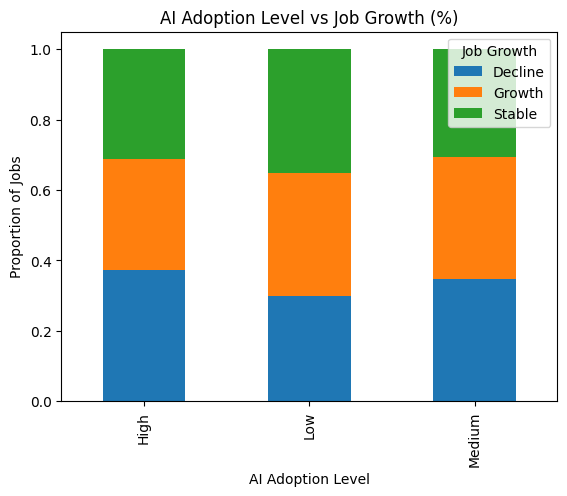

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Create normalized table (percentages)
cross_tab = pd.crosstab(
    df["AI_Adoption_Level"], 
    df["Job_Growth_Projection"], 
    normalize="index"
)

# Plot
cross_tab.plot(kind="bar", stacked=True)

plt.title("AI Adoption Level vs Job Growth (%)")
plt.xlabel("AI Adoption Level")
plt.ylabel("Proportion of Jobs")

plt.legend(title="Job Growth")
plt.show()

## AI Adoption vs Automation Risk

This chart explores how automation risk varies across different levels of AI adoption. Interestingly, the results indicate that higher AI adoption does not necessarily correspond to higher automation risk. In some cases, jobs with lower or medium AI adoption still exhibit considerable levels of risk. This implies that the relationship between AI and automation is not straightforward. Rather than uniformly increasing risk, AI may also complement human work, particularly in more advanced roles. Therefore, AI adoption alone is not a reliable predictor of whether a job is likely to be automated.

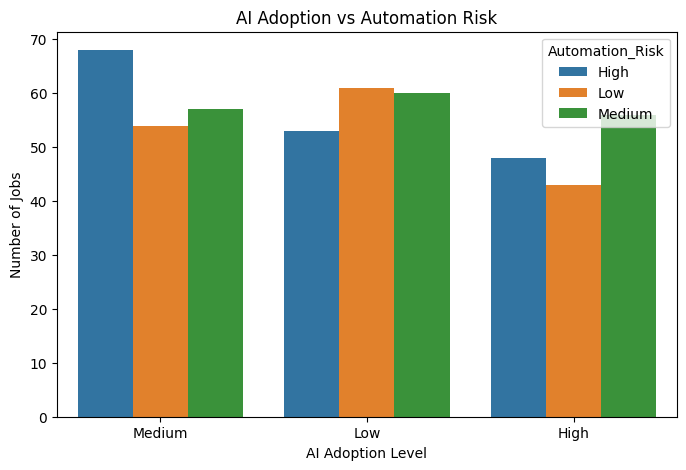

In [16]:
import seaborn as sns


plt.figure(figsize=(8,5))
sns.countplot(data=df, x="AI_Adoption_Level", hue="Automation_Risk")

plt.title("AI Adoption vs Automation Risk")
plt.xlabel("AI Adoption Level")
plt.ylabel("Number of Jobs")

plt.show()


## Salary Distribution by AI Adoption Level

This boxplot illustrates how salaries differ depending on the level of AI adoption in jobs. The results show that positions with high AI adoption tend to have higher median salaries, as well as a wider distribution of pay. This indicates the presence of more high-paying roles within AI-intensive fields. On the other hand, jobs with low AI adoption are generally concentrated in lower salary ranges. This pattern suggests that AI-related roles often require specialized skills, which are rewarded with higher compensation. Consequently, AI adoption appears to be positively associated with earning potential.

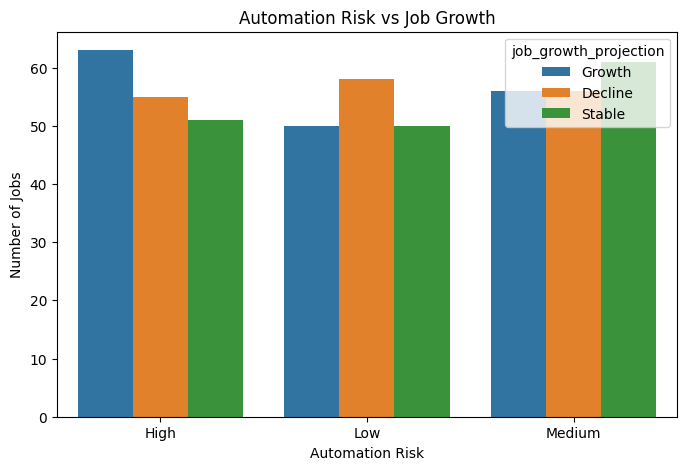

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="automation_risk", hue="job_growth_projection")

plt.title("Automation Risk vs Job Growth")
plt.xlabel("Automation Risk")
plt.ylabel("Number of Jobs")

plt.show()

## Average Job Growth By Industry

This visualization presents the average job growth rate across different industries by converting job growth into a numeric measure and calculating the mean for each sector. The results highlight clear differences in how industries are responding to current labor market trends. Some industries exhibit higher average growth rates, indicating that a larger proportion of jobs within those sectors are expanding. In contrast, other industries show lower growth rates, suggesting slower expansion or a greater presence of declining roles. This variation implies that the impact of technological change, including AI adoption, is not uniform across industries. Instead, certain sectors appear to be better positioned to adapt and benefit from these changes, while others may face more challenges. Overall, the chart emphasizes the importance of industry context when analyzing job growth patterns in the evolving labor market.

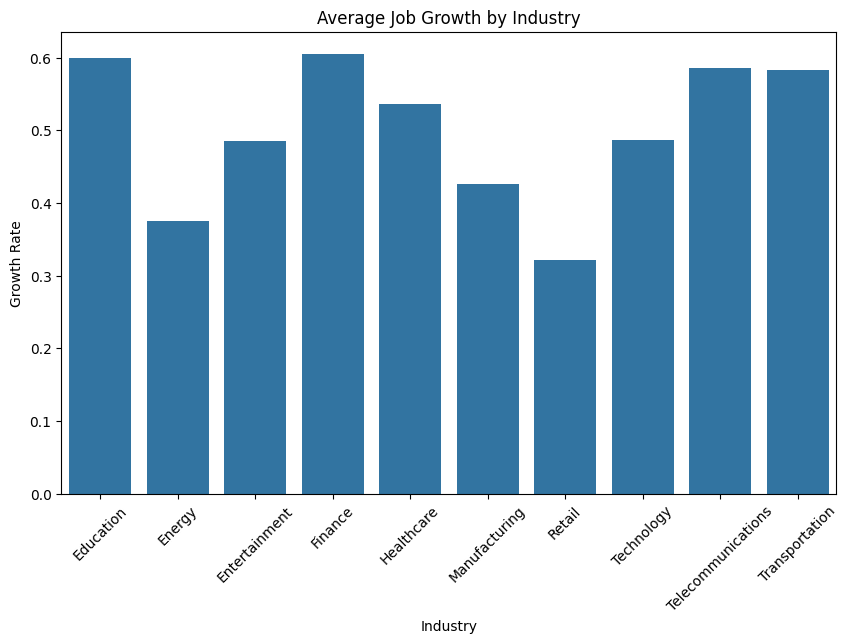

In [17]:
# Convert growth to numeric
df["Growth_Numeric"] = df["job_growth_projection"].map({"Growth": 1, "Decline": 0})

industry_growth = df.groupby("industry")["Growth_Numeric"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=industry_growth, x="industry", y="Growth_Numeric")

plt.title("Average Job Growth by Industry")
plt.xlabel("Industry")
plt.ylabel("Growth Rate")

plt.xticks(rotation=45)
plt.show()

## Salary Distribution by AI Adoption Level

This boxplot illustrates how salaries differ depending on the level of AI adoption in jobs. The results show that positions with high AI adoption tend to have higher median salaries, as well as a wider distribution of pay. This indicates the presence of more high-paying roles within AI-intensive fields. On the other hand, jobs with low AI adoption are generally concentrated in lower salary ranges. This pattern suggests that AI-related roles often require specialized skills, which are rewarded with higher compensation. Consequently, AI adoption appears to be positively associated with earning potential.

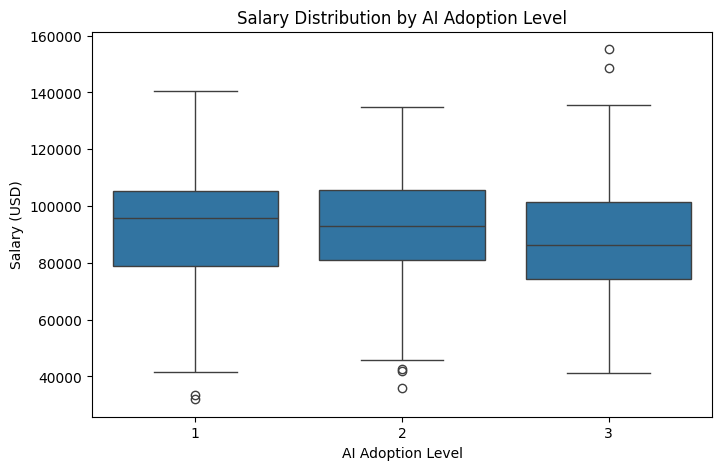

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ai_adoption_level", y="salary_usd")

plt.title("Salary Distribution by AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Salary (USD)")

plt.show()

## Salary Distribution by Automation Risk

This visualization examines the relationship between salary levels and automation risk. The chart indicates that jobs with low automation risk generally offer higher salaries, while high-risk jobs are more concentrated in lower salary ranges. This suggests that roles which are difficult to automate—often requiring complex decision-making, creativity, or advanced technical skills—are more highly valued in the labor market. In contrast, jobs that are more routine and easier to automate tend to offer lower wages. Overall, the results highlight a negative relationship between automation risk and salary.

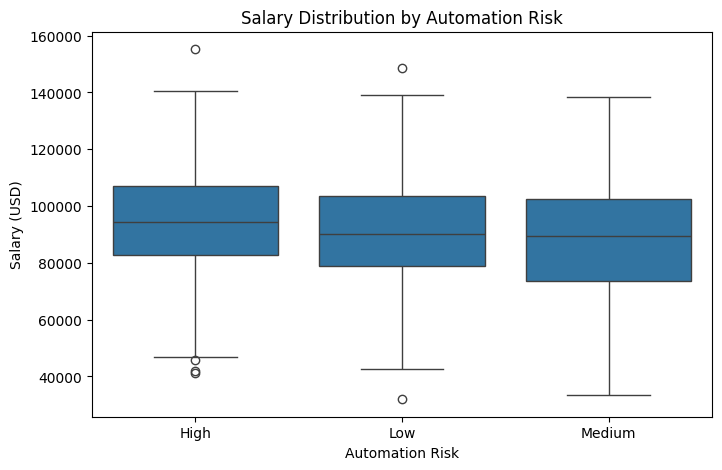

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="automation_risk", y="salary_usd")

plt.title("Salary Distribution by Automation Risk")
plt.xlabel("Automation Risk")
plt.ylabel("Salary (USD)")

plt.show()

## High Growth & Low Automation Risk Jobs by Industry

This bar chart focuses on industries that contain jobs characterized by both high growth and low automation risk. These roles represent particularly attractive career opportunities, as they combine stability with strong future demand. The visualization reveals that certain industries stand out by having a higher concentration of such jobs, indicating that they are better positioned to benefit from ongoing technological changes. This suggests that the impact of AI is not uniform across sectors, and that some industries are more resilient and adaptable than others in the face of automation.

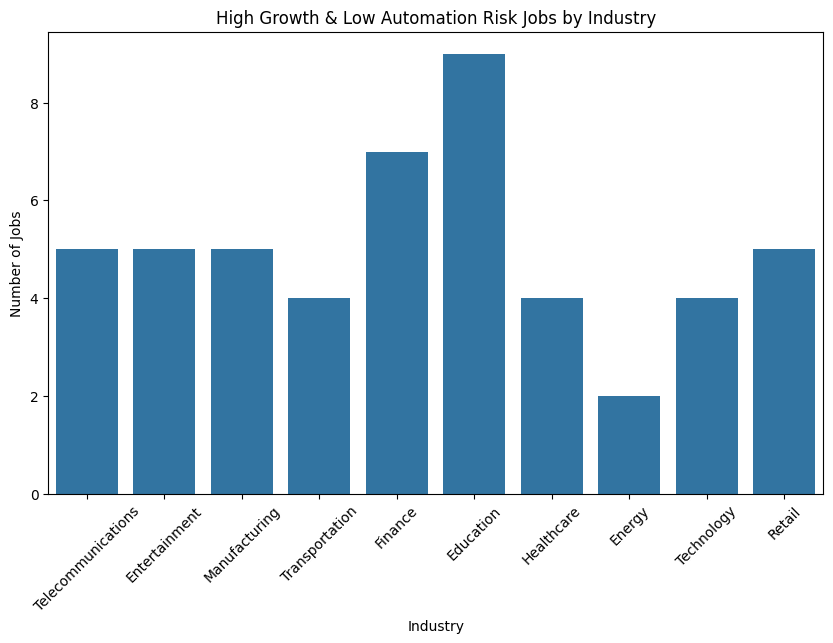

In [25]:
filtered_df = df[
    (df["job_growth_projection"] == "Growth") &
    (df["automation_risk"] == "Low")
]

plt.figure(figsize=(10,6))
sns.countplot(data=filtered_df, x="industry")

plt.title("High Growth & Low Automation Risk Jobs by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.show()

## Top 10 Most In-Demand Skills

This chart presents the most frequently required skills across the job dataset. The results highlight a combination of technical and non-technical skills, with programming, data-related, and AI-focused skills such as Python, machine learning, and data analysis appearing prominently. At the same time, skills like communication and project management are also highly represented. This indicates that employers are not only seeking technical expertise but also value soft skills that support collaboration and effective problem-solving. Overall, the findings suggest that a balanced skill set is increasingly important in the modern job market.

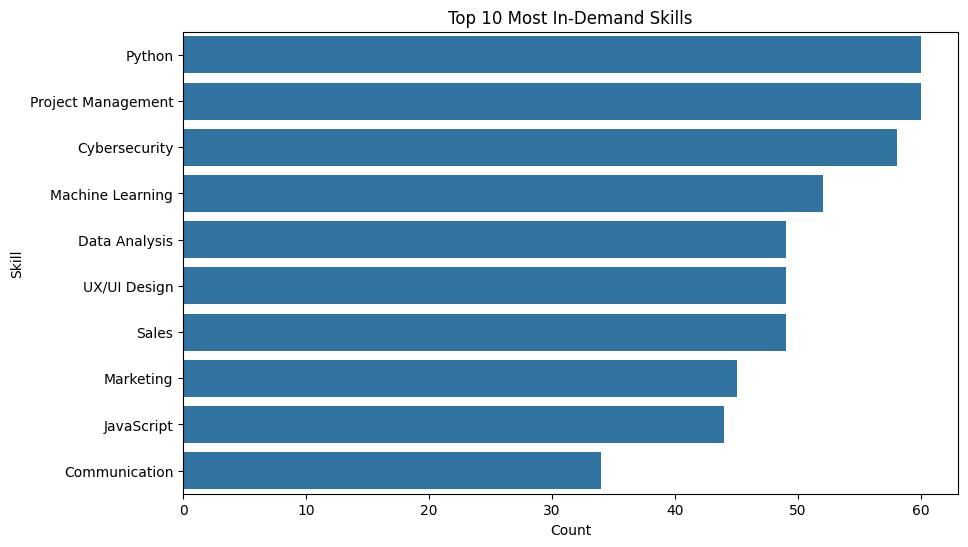

In [27]:
from collections import Counter

# Split skills (assuming comma-separated)
skills = df["required_skills"].dropna().str.split(", ")

# Flatten list
all_skills = [skill for sublist in skills for skill in sublist]

# Count frequencies
skill_counts = Counter(all_skills)

# Convert to DataFrame
skills_df = pd.DataFrame(skill_counts.items(), columns=["Skill", "Count"])
skills_df = skills_df.sort_values(by="Count", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=skills_df, x="Count", y="Skill")

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Count")
plt.ylabel("Skill")

plt.show()

## Correlation Heatmap

The correlation heatmap provides an overview of the relationships between key variables, including AI adoption, automation risk, job growth, and salary. The results show that most correlations are relatively weak, indicating that there are no strong linear relationships between these variables. This suggests that the dynamics of the job market in the context of AI are complex and influenced by multiple interacting factors. Rather than being driven by a single variable, outcomes such as job growth and salary appear to depend on a combination of elements, including skills, industry, and the nature of the work itself.

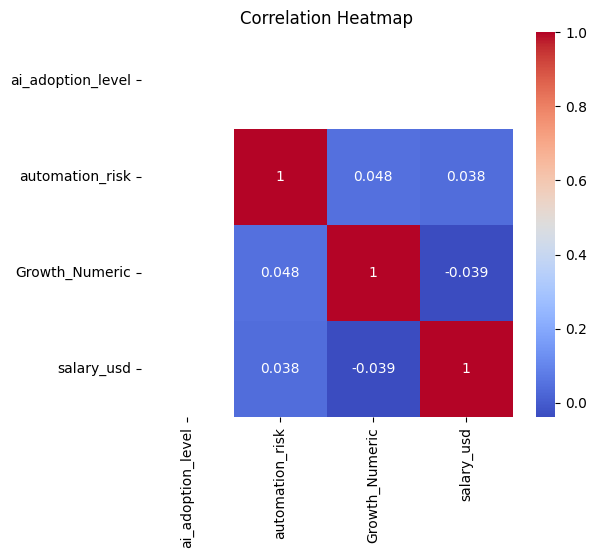

In [34]:
# Convert categorical to numeric for correlation
df_corr = df.copy()
df_corr["ai_adoption_level"] = df_corr["ai_adoption_level"].map({"Low": 1, "Medium": 2, "High": 3})
df_corr["automation_risk"] = df_corr["automation_risk"].map({"Low": 1, "Medium": 2, "High": 3})

# Add Growth_Numeric to df_corr
df_corr["Growth_Numeric"] = df_corr["job_growth_projection"].map({"Growth": 1, "Decline": 0, "Stable": 0.5})

# Create correlation matrix
corr = df_corr[["ai_adoption_level", "automation_risk", "Growth_Numeric", "salary_usd"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()